> ### Note on Labs and Assigments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action!
>
> These sections are graded and are not optional.
>

# **IS4487 Module 4 - Assignment**

### Outline

Our Goals with this Project:

1. Import the data
2. Examine or profile the data: assess the shape, data types, distributions, missing values or inconsistencies
3. Perform Exploratory Data Analysis (EDA): create visualizations to better understand the variables and relationships in the data

<a href="https://colab.research.google.com/github/vandanara/UofUtah_IS4487/blob/main/Assignments/assignment_04_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Business Case: AdviseInvest
You work on a small team of data analysts at AdviseInvest, a venture-backed startup. The Director of Sales at AdviseInvest has approached your team asking for help solving a staffing problem.

### The Company
The company's mission is to provide tools and support to help ordinary people gain control of their personal finances. The company leverages technology to provide affordable financial advice to a national client base.

Customers who reach AdviseInvest's website go through five steps:

- Open an account.
- Complete a customer profile form with basic information about their background and finances.
- Schedule a free phone conversation with a sales representative during a 1-hour window of time.
- Attend the free phone conversation.
- Buy a financial plan.
- There are three types of financial plans: Beginner, Intermediate, and Advanced. Each is sold at a different price, and there are varying degrees of personalization. After a customer purchases a financial plan, the customer is assigned a financial planner who helps determine the customer's goals and advises the customer on spending decisions.

### The Problem
Some customers are lost at each stage of the process. Steps 3 and 4 are particularly challenging because approximately 50% of those who schedule a phone conversation fail to pick up the call. This leads to inefficiencies from a staffing perspective.

AdviseInvest has 4 sales reps on staff during each particular 1-hour window. Each of the 4 reps is assigned 2 prospective customers per hour, which means that the company schedules a total of 8 phone calls per hour. The calls are outgoing: sales reps call customers who scheduled a phone conversation during that hour window.

Unfortunately, as noted above, many of the customers who scheduled a call do not answer. As a consequence, sales reps are often left underutilized. Moreover, they are underutilized unevenly. For example, it is possible that one sales rep will not do any sales calls during that hour, whereas another will be busy the entire hour with two calls. Sales reps have nothing to do when customers do not answer the scheduled phone call.

For this assignment, the variable `answered` is your target.  


### AdviseInvest Data Dictionary

| Variable | Description | Type | Code |
|:---|:---|:---|:---|
| Answered | Customer response | Binary | 0: customer did not answer scheduled call; 1: customer answered scheduled call |
| Income | Customer income in US dollars | Numeric | |
| Female | Customer gender | Binary | 0: female; 1: male |
| Age | Age in years | Numeric | |
| Job | Nature of job | Categorical | 0 : unemployed; 1 : entry level position; 2 : midlevel position; 3 : management/ self-employed/ highly qualified employee/ officer |
| Num_dependents | Number of people for whom the customer provides maintenance | Numeric | |
| Rent | Customer rents | Binary | 0: no; 1: yes |
| Own_res | Customer owns residence | Binary | 0: no; 1: yes |
| New_car | Recent new car purchase | Binary | New car purchase in the last 3 months: 0: no, 1: yes |
| Chk_acct | Checking account status | Categorical | 0 : no checking account; 1: checking < 200 USD; 2 : 200 < checking < 2000 USD; 3: 2000 < checking < 35000 USD; 4: >= 3500 USD |
| Sav_acct | Average balance in savings account | Categorical | 0 : no savings account; 1 : 100 <= savings < 500 USD; 2 : 500 <= savings < 2000 USD; 3 : 2000 < savings < 35000 USD; 4: >= 3500 USD |
| Num_accts | Number of accounts owned by customer | Numeric | |
| Mobile | Mobile phone | Binary | 0: customer provided non‐mobile phone for follow‐up call; 1: customer provided mobile phone for follow‐up call |
| Product | Type of product purchased after conversation with sales rep | Categorical | 0: customer did not answer call; 1: customer answered but did not purchase a product; 2: customer answered and purchased Beginner plan; 3: customer answered and purchased Intermediate plan; 4: customer answered and purchased Advanced plan |


## 🔧 **Task 1: Import the libraries and load the data**

🔧 1.1. Import the libraries you will need, such as:
- Pandas
- Matplotlib
- Seaborn


In [26]:
# 🔧 1.1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


🔧 1.2. Load data

Import data from the AdviseInvest historical dataset into a dataframe.

- In GitHub go to the folder called DataSets, search for a dataset called ***"adviseinvest_historical_data.csv"***
- Click on it and it will take you to a data display page.
- Click on the *'Raw'* button at the top right of the page.
- Then on the next page that follows, copy the url of raw dataset. This is what you want to enter as the url for `pd.read_csv()`



In [27]:
# 🔧 1.2. Import the data
url = "https://raw.githubusercontent.com/vandanara/UofUtah_IS4487/refs/heads/main/DataSets/adviseinvest_historical_data.csv"
adviseinvest = pd.read_csv(url)

adviseinvest.head()

,answered,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
0,1,13520,0,23,0,1,1,0,0.0,0,2,0,1,2
1,0,14780,0,22,2,1,0,1,0.0,3,0,3,0,0
2,1,37570,0,62,2,1,0,0,1.0,3,0,4,0,4
3,0,12450,0,33,2,1,0,1,0.0,1,0,2,0,0
4,0,12400,0,48,1,2,0,0,1.0,2,1,4,0,0


## **Task 2: Initial Data Understanding: examine or profile the data**

🔧 2.1. Obtain the shape of the table (rows and columns).

🔧 2.2. Profile the dataframe - obtain data types, counts of variables, missing values.

🔧 2.3. Are there any duplicate rows?

🔧 2.4. Describe the dataframe (i.e. obtain min, max, mean, std dev, percentiles etc).



In [28]:
# 🔧 2.1. View the shape of the data
adviseinvest.shape


(29504, 14)

In [29]:
# 🔧 2.2. View the datatypes, counts and missing values
adviseinvest.info()
adviseinvest.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29504 entries, 0 to 29503
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   answered        29504 non-null  int64  
 1   income          29504 non-null  int64  
 2   female          29504 non-null  object 
 3   age             29504 non-null  int64  
 4   job             29504 non-null  int64  
 5   num_dependents  29504 non-null  int64  
 6   rent            29504 non-null  int64  
 7   own_res         29504 non-null  int64  
 8   new_car         29502 non-null  float64
 9   chk_acct        29504 non-null  int64  
 10  sav_acct        29504 non-null  int64  
 11  num_accts       29504 non-null  int64  
 12  mobile          29504 non-null  int64  
 13  product         29504 non-null  int64  
dtypes: float64(1), int64(12), object(1)
memory usage: 3.2+ MB


,0
answered,0
income,0
female,0
age,0
job,0
num_dependents,0
rent,0
own_res,0
new_car,2
chk_acct,0


In [30]:
# 🔧 2.3. Check for duplicated rows
adviseinvest.duplicated().sum()

np.int64(29035)

In [31]:
# 🔧 2.4. Describe the data's numerical columns (i.e. obtain min, max, mean, std dev, percentiles etc).
adviseinvest.describe()


,answered,income,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
count,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29502.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000
mean,0.546638,33766.893303,34.773454,1.915401,1.140998,0.210412,0.681128,0.240797,1.468547,0.956616,2.458345,0.091106,1.535792
std,0.497829,29379.202710,11.369865,0.658183,0.348025,0.407608,0.466047,0.427575,1.234727,1.483946,19.497380,0.287765,1.625916
min,0.000000,-65600.000000,19.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,13550.000000,26.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000
50%,1.000000,23310.000000,32.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,1.000000
75%,1.000000,41690.000000,40.000000,2.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,3.000000
max,1.000000,159450.000000,132.000000,3.000000,2.000000,1.000000,1.000000,1.000000,3.000000,4.000000,3345.000000,1.000000,4.000000


### 🔧Please answer the following:

2.5. Do you see any variables that have potential outliers? What indicators do you see the the values are out of the normal range? (don't worry about using a scientific approach for outliers at this stage; just use your best judgment)

### ✍️ Your response: 🔧

2.5.Yes, there are some potential outliers. Age has a maximum value of 132, which is unusually high. Income also has a minimum value of -65,600, which may be an error or unusual case. Num_accts has a maximum of 3,345 while the median is only 2, so this also appears to be a strong outlier.



## **Task 3: Explore the data - create visualizations**

Explore the relationships between the target and independent variables. You can assume that  `Answered` is the target variable.

🔧 3.1. - 3.5. Create at least five charts to show the relationships, using different chart types that are approriate to the analysis. Ensure that all charts are clearly labeled and formatted

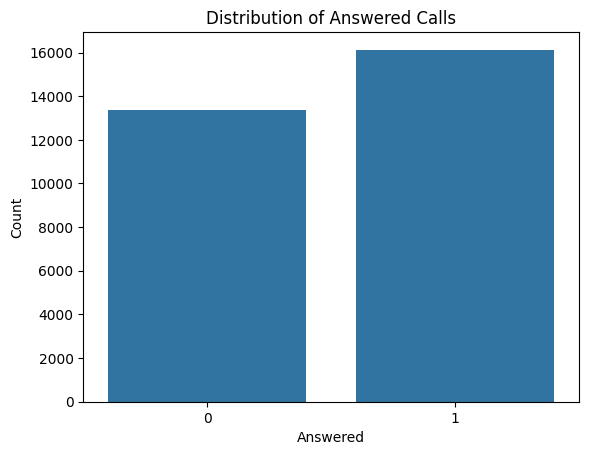

In [32]:
# 🔧 3.1. Chart 1
sns.countplot(data=adviseinvest, x="answered")
plt.title("Distribution of Answered Calls")
plt.xlabel("Answered")
plt.ylabel("Count")
plt.show()

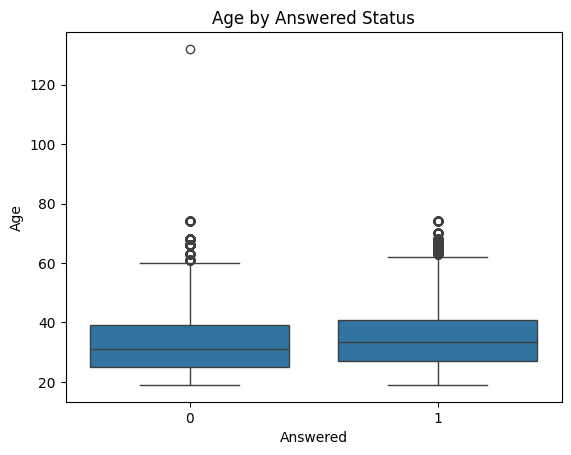

In [33]:
# 🔧 3.2. Chart 2
sns.boxplot(data=adviseinvest, x="answered", y="age")
plt.title("Age by Answered Status")
plt.xlabel("Answered")
plt.ylabel("Age")
plt.show()

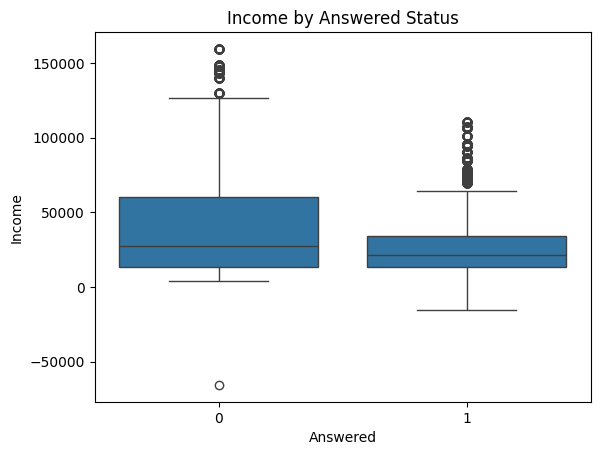

In [34]:
# 🔧 3.3. Chart 3
sns.boxplot(data=adviseinvest, x="answered", y="income")
plt.title("Income by Answered Status")
plt.xlabel("Answered")
plt.ylabel("Income")
plt.show()

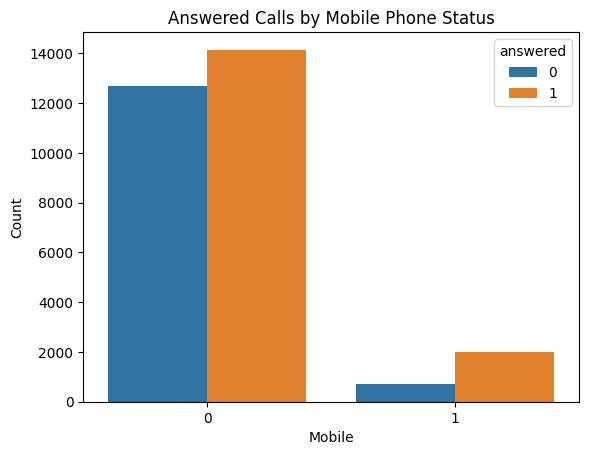

In [35]:
# 🔧 3.4. Chart 4
sns.countplot(data=adviseinvest, x="mobile", hue="answered")
plt.title("Answered Calls by Mobile Phone Status")
plt.xlabel("Mobile")
plt.ylabel("Count")
plt.show()

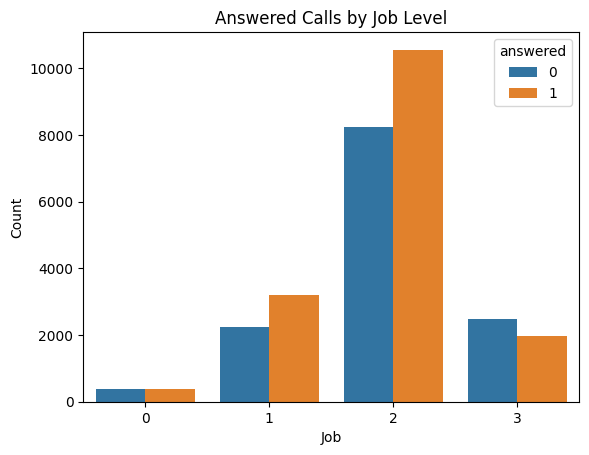

In [36]:
# 🔧 3.5. Chart 5
sns.countplot(data=adviseinvest, x="job", hue="answered")
plt.title("Answered Calls by Job Level")
plt.xlabel("Job")
plt.ylabel("Count")
plt.show()

## **Task 4: Summarize Your Findings**

### 🔧 Please answer the following:

 4.1.Not all variables are equally useful. Variables such as age, income, job, mobile, and financial information may be related to whether a customer answers the call. Product should not be used to predict Answered because the product value already tells us whether the customer answered the call, which could cause data leakage.

 4.2.The dataset has several data quality issues. There are two missing values in new_car and a large number of duplicate rows. There are also unusual values such as age of 132, negative income, and 3,345 accounts. The female variable is stored as an object and some categorical variables are stored as numbers, so the data types should also be reviewed.

### ✍️ Your response: 🔧

4.1.Not all variables are equally useful for the business need. Variables such as age, income, job, mobile, and financial information may help explain whether a customer answers a scheduled call. However, Product should probably not be used to predict Answered because its value already depends on whether the customer answered the call. This could create data leakage.


4.2The dataset could be improved by checking missing values, duplicate records, unusual values, and incorrect data types. Categorical variables such as job and account status should be treated as categorical rather than continuous numerical variables. The variable definitions and coding should also be checked for consistency before building a model.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully in your own words
- Save the file with your last name and first name as shown below (see detailed instructions in Lab 1 on how to do this).
- Submit the assignment as an **HTML file** on Canvas

In [37]:
!jupyter nbconvert --to html "assignment_04_WangJiaxu.ipynb"

[NbConvertApp] WARNING | pattern 'assignment_04_WangJiaxu.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
-